In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

In [2]:
df = pd.read_csv('laptop_prices_100k.csv')

In [3]:
df

,brand,processor_brand,processor_name,ram_gb,storage_gb,storage_type,gpu,screen_size_inch,screen_resolution,os,battery_life_hrs,weight_kg,touchscreen,backlit_keyboard,num_usb_ports,warranty_years,usage_type,price_usd
0,Lenovo,AMD,Ryzen 9 Gen11,16,256,SSD,Integrated,16.0,1920x1080,Linux,4.0,3.22,0,0,2,2,Workstation,1045.75
1,Razer,Intel,Core i5 Gen13,16,512,HDD,Integrated,14.0,1920x1080,Linux,6.9,3.18,0,1,3,1,Gaming,1409.73
2,Asus,AMD,A-Series Gen13,8,256,SSD,Integrated,13.3,2560x1440,Windows 10,17.1,1.09,1,1,4,3,Ultrabook,1155.24
3,Apple,Apple,M1,16,512,SSD,Apple GPU,17.3,2560x1600,macOS,10.2,3.41,0,1,1,2,Ultrabook,1698.70
4,Dell,Intel,Core i7 Gen13,8,256,NVMe SSD,NVIDIA RTX,14.0,2560x1440,Windows 10,5.7,2.84,0,0,3,3,Gaming,1827.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Acer,Intel,Core i5 Gen10,16,256,NVMe SSD,Integrated,15.6,2560x1440,Windows 10,6.7,2.38,1,1,2,3,Student,1161.28
99996,Acer,AMD,Ryzen 9 Gen14,16,512,SSD,AMD Radeon,17.3,1920x1080,Windows 11,10.3,1.28,0,1,4,2,Ultrabook,1537.50
99997,Asus,Intel,Core i7 Gen10,8,512,NVMe SSD,NVIDIA RTX,15.6,2560x1440,Windows 11,17.5,3.42,0,1,2,2,Budget,1743.65
99998,Lenovo,Intel,Pentium Gen12,16,128,NVMe SSD,NVIDIA GTX,15.6,2560x1600,Windows 10,5.3,2.95,1,1,2,1,Budget,1124.76


In [4]:
df.head()

,brand,processor_brand,processor_name,ram_gb,storage_gb,storage_type,gpu,screen_size_inch,screen_resolution,os,battery_life_hrs,weight_kg,touchscreen,backlit_keyboard,num_usb_ports,warranty_years,usage_type,price_usd
0,Lenovo,AMD,Ryzen 9 Gen11,16,256,SSD,Integrated,16.0,1920x1080,Linux,4.0,3.22,0,0,2,2,Workstation,1045.75
1,Razer,Intel,Core i5 Gen13,16,512,HDD,Integrated,14.0,1920x1080,Linux,6.9,3.18,0,1,3,1,Gaming,1409.73
2,Asus,AMD,A-Series Gen13,8,256,SSD,Integrated,13.3,2560x1440,Windows 10,17.1,1.09,1,1,4,3,Ultrabook,1155.24
3,Apple,Apple,M1,16,512,SSD,Apple GPU,17.3,2560x1600,macOS,10.2,3.41,0,1,1,2,Ultrabook,1698.70
4,Dell,Intel,Core i7 Gen13,8,256,NVMe SSD,NVIDIA RTX,14.0,2560x1440,Windows 10,5.7,2.84,0,0,3,3,Gaming,1827.86


In [5]:
df.tail()

,brand,processor_brand,processor_name,ram_gb,storage_gb,storage_type,gpu,screen_size_inch,screen_resolution,os,battery_life_hrs,weight_kg,touchscreen,backlit_keyboard,num_usb_ports,warranty_years,usage_type,price_usd
99995,Acer,Intel,Core i5 Gen10,16,256,NVMe SSD,Integrated,15.6,2560x1440,Windows 10,6.7,2.38,1,1,2,3,Student,1161.28
99996,Acer,AMD,Ryzen 9 Gen14,16,512,SSD,AMD Radeon,17.3,1920x1080,Windows 11,10.3,1.28,0,1,4,2,Ultrabook,1537.50
99997,Asus,Intel,Core i7 Gen10,8,512,NVMe SSD,NVIDIA RTX,15.6,2560x1440,Windows 11,17.5,3.42,0,1,2,2,Budget,1743.65
99998,Lenovo,Intel,Pentium Gen12,16,128,NVMe SSD,NVIDIA GTX,15.6,2560x1600,Windows 10,5.3,2.95,1,1,2,1,Budget,1124.76
99999,Lenovo,Intel,Core i3 Gen10,4,1000,NVMe SSD,Integrated,15.6,2560x1440,Windows 10,14.4,1.36,1,1,3,1,Ultrabook,913.02


In [6]:
df.shape

(100000, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   brand              100000 non-null  object 
 1   processor_brand    100000 non-null  object 
 2   processor_name     100000 non-null  object 
 3   ram_gb             100000 non-null  int64  
 4   storage_gb         100000 non-null  int64  
 5   storage_type       100000 non-null  object 
 6   gpu                100000 non-null  object 
 7   screen_size_inch   100000 non-null  float64
 8   screen_resolution  100000 non-null  object 
 9   os                 100000 non-null  object 
 10  battery_life_hrs   100000 non-null  float64
 11  weight_kg          100000 non-null  float64
 12  touchscreen        100000 non-null  int64  
 13  backlit_keyboard   100000 non-null  int64  
 14  num_usb_ports      100000 non-null  int64  
 15  warranty_years     100000 non-null  int64  
 16  usa

In [8]:
df.describe()

,ram_gb,storage_gb,screen_size_inch,battery_life_hrs,weight_kg,touchscreen,backlit_keyboard,num_usb_ports,warranty_years,price_usd
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,17.419800,662.594800,14.861949,11.006600,2.249843,0.354550,0.699890,2.499370,1.597690,1363.279122
std,13.852804,491.100682,1.436732,4.039757,0.720842,0.478379,0.458308,1.118916,0.732654,371.601752
min,4.000000,128.000000,11.600000,4.000000,1.000000,0.000000,0.000000,1.000000,1.000000,426.370000
25%,8.000000,256.000000,14.000000,7.500000,1.630000,0.000000,0.000000,1.000000,1.000000,1087.387500
50%,16.000000,512.000000,15.600000,11.000000,2.250000,0.000000,1.000000,2.000000,1.000000,1331.225000
75%,16.000000,1000.000000,15.600000,14.500000,2.870000,1.000000,1.000000,4.000000,2.000000,1611.472500
max,64.000000,2000.000000,17.300000,18.000000,3.500000,1.000000,1.000000,4.000000,3.000000,3173.550000


In [9]:
df.isnull().sum()

brand                0
processor_brand      0
processor_name       0
ram_gb               0
storage_gb           0
storage_type         0
gpu                  0
screen_size_inch     0
screen_resolution    0
os                   0
battery_life_hrs     0
weight_kg            0
touchscreen          0
backlit_keyboard     0
num_usb_ports        0
warranty_years       0
usage_type           0
price_usd            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['brand'].value_counts()

brand
Dell         18036
HP           17130
Lenovo       16827
Apple        12010
Asus         10106
Acer         10012
MSI           7048
Samsung       3960
Razer         2926
Microsoft     1945
Name: count, dtype: int64

In [12]:
df['processor_name'].value_counts()

processor_name
M1                2038
M3 Pro            2014
M2                2011
M3                1991
M2 Pro            1991
                  ... 
Ryzen 3 Gen13     1285
Ryzen 5 Gen10     1277
Ryzen 5 Gen14     1276
A-Series Gen11    1273
Ryzen 9 Gen10     1267
Name: count, Length: 61, dtype: int64

In [13]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

brand 10
processor_brand 3
processor_name 61
storage_type 3
gpu 5
screen_resolution 5
os 5
usage_type 6


In [14]:
df['price'] = round(df['price_usd']*91.94, 2)

In [15]:
df

,brand,processor_brand,processor_name,ram_gb,storage_gb,storage_type,gpu,screen_size_inch,screen_resolution,os,battery_life_hrs,weight_kg,touchscreen,backlit_keyboard,num_usb_ports,warranty_years,usage_type,price_usd,price
0,Lenovo,AMD,Ryzen 9 Gen11,16,256,SSD,Integrated,16.0,1920x1080,Linux,4.0,3.22,0,0,2,2,Workstation,1045.75,96146.26
1,Razer,Intel,Core i5 Gen13,16,512,HDD,Integrated,14.0,1920x1080,Linux,6.9,3.18,0,1,3,1,Gaming,1409.73,129610.58
2,Asus,AMD,A-Series Gen13,8,256,SSD,Integrated,13.3,2560x1440,Windows 10,17.1,1.09,1,1,4,3,Ultrabook,1155.24,106212.77
3,Apple,Apple,M1,16,512,SSD,Apple GPU,17.3,2560x1600,macOS,10.2,3.41,0,1,1,2,Ultrabook,1698.70,156178.48
4,Dell,Intel,Core i7 Gen13,8,256,NVMe SSD,NVIDIA RTX,14.0,2560x1440,Windows 10,5.7,2.84,0,0,3,3,Gaming,1827.86,168053.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Acer,Intel,Core i5 Gen10,16,256,NVMe SSD,Integrated,15.6,2560x1440,Windows 10,6.7,2.38,1,1,2,3,Student,1161.28,106768.08
99996,Acer,AMD,Ryzen 9 Gen14,16,512,SSD,AMD Radeon,17.3,1920x1080,Windows 11,10.3,1.28,0,1,4,2,Ultrabook,1537.50,141357.75
99997,Asus,Intel,Core i7 Gen10,8,512,NVMe SSD,NVIDIA RTX,15.6,2560x1440,Windows 11,17.5,3.42,0,1,2,2,Budget,1743.65,160311.18
99998,Lenovo,Intel,Pentium Gen12,16,128,NVMe SSD,NVIDIA GTX,15.6,2560x1600,Windows 10,5.3,2.95,1,1,2,1,Budget,1124.76,103410.43


In [16]:
df.drop('price_usd', axis=1, inplace=True)

In [17]:
df

,brand,processor_brand,processor_name,ram_gb,storage_gb,storage_type,gpu,screen_size_inch,screen_resolution,os,battery_life_hrs,weight_kg,touchscreen,backlit_keyboard,num_usb_ports,warranty_years,usage_type,price
0,Lenovo,AMD,Ryzen 9 Gen11,16,256,SSD,Integrated,16.0,1920x1080,Linux,4.0,3.22,0,0,2,2,Workstation,96146.26
1,Razer,Intel,Core i5 Gen13,16,512,HDD,Integrated,14.0,1920x1080,Linux,6.9,3.18,0,1,3,1,Gaming,129610.58
2,Asus,AMD,A-Series Gen13,8,256,SSD,Integrated,13.3,2560x1440,Windows 10,17.1,1.09,1,1,4,3,Ultrabook,106212.77
3,Apple,Apple,M1,16,512,SSD,Apple GPU,17.3,2560x1600,macOS,10.2,3.41,0,1,1,2,Ultrabook,156178.48
4,Dell,Intel,Core i7 Gen13,8,256,NVMe SSD,NVIDIA RTX,14.0,2560x1440,Windows 10,5.7,2.84,0,0,3,3,Gaming,168053.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Acer,Intel,Core i5 Gen10,16,256,NVMe SSD,Integrated,15.6,2560x1440,Windows 10,6.7,2.38,1,1,2,3,Student,106768.08
99996,Acer,AMD,Ryzen 9 Gen14,16,512,SSD,AMD Radeon,17.3,1920x1080,Windows 11,10.3,1.28,0,1,4,2,Ultrabook,141357.75
99997,Asus,Intel,Core i7 Gen10,8,512,NVMe SSD,NVIDIA RTX,15.6,2560x1440,Windows 11,17.5,3.42,0,1,2,2,Budget,160311.18
99998,Lenovo,Intel,Pentium Gen12,16,128,NVMe SSD,NVIDIA GTX,15.6,2560x1600,Windows 10,5.3,2.95,1,1,2,1,Budget,103410.43


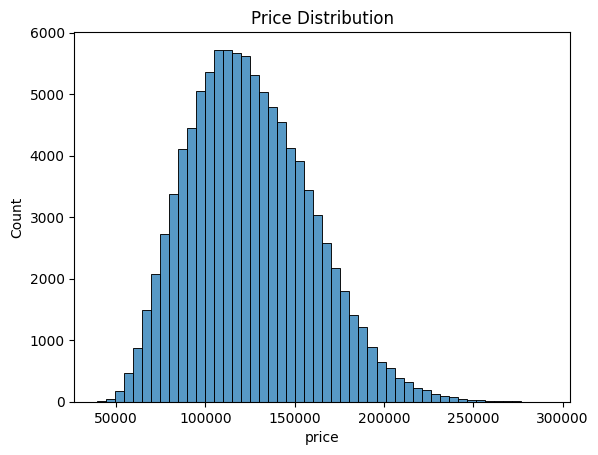

In [18]:
sns.histplot(df['price'], bins=50)
plt.title('Price Distribution')
plt.show()

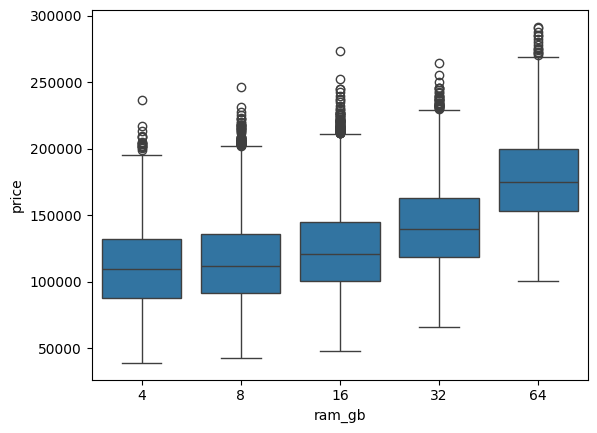

In [19]:
sns.boxplot(x=df['ram_gb'], y=df['price'])
plt.show()

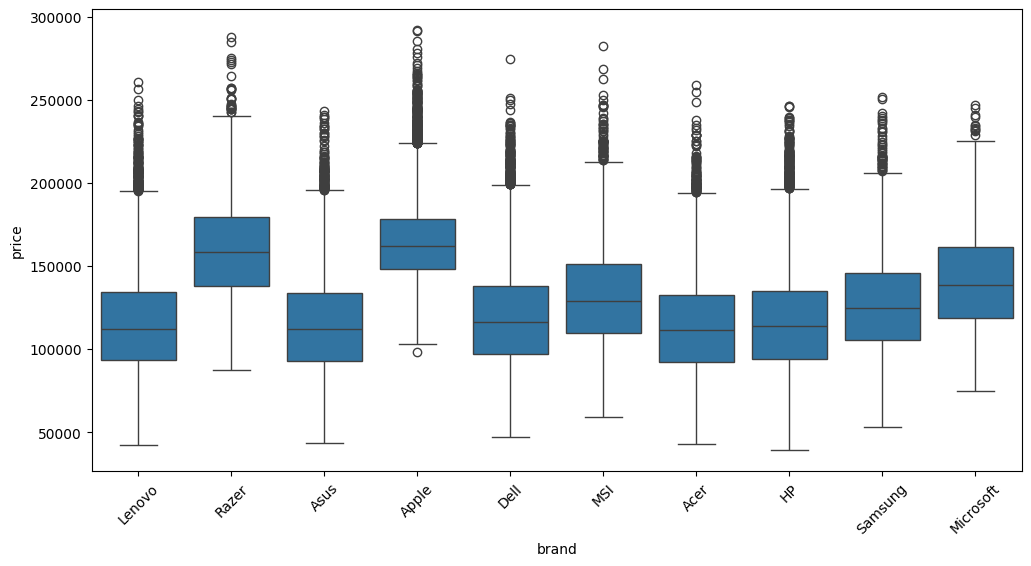

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df['brand'], y=df['price'])
plt.xticks(rotation=45)
plt.show()

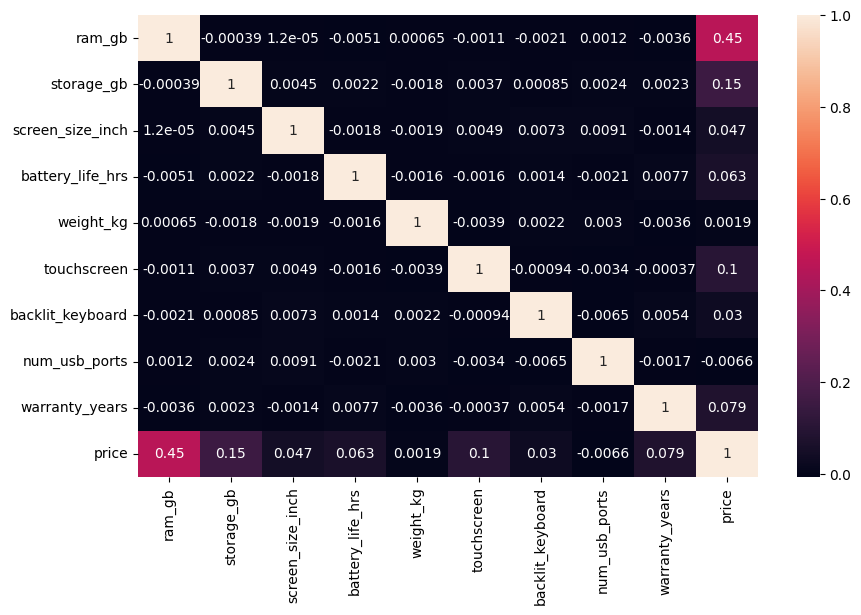

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [22]:
df["resolution_width"] = df["screen_resolution"].apply(lambda x: int(x.split("x")[0]))
df["resolution_height"] = df["screen_resolution"].apply(lambda x: int(x.split("x")[1]))

df.drop("screen_resolution", axis=1, inplace=True)

In [23]:
df

,brand,processor_brand,processor_name,ram_gb,storage_gb,storage_type,gpu,screen_size_inch,os,battery_life_hrs,weight_kg,touchscreen,backlit_keyboard,num_usb_ports,warranty_years,usage_type,price,resolution_width,resolution_height
0,Lenovo,AMD,Ryzen 9 Gen11,16,256,SSD,Integrated,16.0,Linux,4.0,3.22,0,0,2,2,Workstation,96146.26,1920,1080
1,Razer,Intel,Core i5 Gen13,16,512,HDD,Integrated,14.0,Linux,6.9,3.18,0,1,3,1,Gaming,129610.58,1920,1080
2,Asus,AMD,A-Series Gen13,8,256,SSD,Integrated,13.3,Windows 10,17.1,1.09,1,1,4,3,Ultrabook,106212.77,2560,1440
3,Apple,Apple,M1,16,512,SSD,Apple GPU,17.3,macOS,10.2,3.41,0,1,1,2,Ultrabook,156178.48,2560,1600
4,Dell,Intel,Core i7 Gen13,8,256,NVMe SSD,NVIDIA RTX,14.0,Windows 10,5.7,2.84,0,0,3,3,Gaming,168053.45,2560,1440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Acer,Intel,Core i5 Gen10,16,256,NVMe SSD,Integrated,15.6,Windows 10,6.7,2.38,1,1,2,3,Student,106768.08,2560,1440
99996,Acer,AMD,Ryzen 9 Gen14,16,512,SSD,AMD Radeon,17.3,Windows 11,10.3,1.28,0,1,4,2,Ultrabook,141357.75,1920,1080
99997,Asus,Intel,Core i7 Gen10,8,512,NVMe SSD,NVIDIA RTX,15.6,Windows 11,17.5,3.42,0,1,2,2,Budget,160311.18,2560,1440
99998,Lenovo,Intel,Pentium Gen12,16,128,NVMe SSD,NVIDIA GTX,15.6,Windows 10,5.3,2.95,1,1,2,1,Budget,103410.43,2560,1600


In [39]:
X = df.drop('price', axis=1)
y = df['price']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [41]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [42]:
def make_pipeline(model):
    preprocessor = ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
        remainder="passthrough"
    )
    return Pipeline([("preprocesser", preprocessor), ("model", model)])

In [43]:
models = {
    "Linear Regression":   make_pipeline(LinearRegression()),
    "Random Forest":       make_pipeline(RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_split=5, n_jobs=-1, random_state=42)),
    "Gradient Boosting":   make_pipeline(GradientBoostingRegressor(n_estimators=120, learning_rate=0.08, max_depth=4, subsample=0.8, random_state=42)),
}

In [44]:
results = []
trained = {}

In [45]:
print("🚀 Training all models...\n")
print(f"{'Model':<25} {'R2 Score':>10} {'MAE':>12} {'RMSE':>12}")
print("-" * 62)
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    pred  = pipeline.predict(X_test)
    r2    = r2_score(y_test, pred)
    mae   = mean_absolute_error(y_test, pred)
    rmse  = np.sqrt(mean_squared_error(y_test, pred))

    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})
    trained[name] = pipeline

    print(f"{name:<25} {r2:>10.4f} {mae:>12.2f} {rmse:>12.2f}")

🚀 Training all models...

Model                       R2 Score          MAE         RMSE
--------------------------------------------------------------
Linear Regression             0.9178      7657.69      9800.18
Random Forest                 0.7758     13088.09     16183.28
Gradient Boosting             0.8429     10922.80     13547.36


In [46]:
best = max(results, key=lambda x: x["R2"])
best_pipeline = trained[best["Model"]]

print("-" * 62)
print(f"\n🏆 Best Model : {best['Model']}")
print(f"   R2 Score   : {best['R2']:.4f}")
print(f"   MAE        : ₹{best['MAE']:,.2f}")
print(f"   RMSE       : ₹{best['RMSE']:,.2f}")

--------------------------------------------------------------

🏆 Best Model : Linear Regression
   R2 Score   : 0.9178
   MAE        : ₹7,657.69
   RMSE       : ₹9,800.18


In [47]:
test_data = pd.DataFrame([{
    "brand": "Apple", "processor_brand": "Apple", "processor_name": "M2 Pro",
    "ram_gb": 16, "storage_gb": 128, "storage_type": "NVMe SSD",
    "gpu": "Apple GPU", "screen_size_inch": 15.6, "os": "macOS",
    "battery_life_hrs": 14.0, "weight_kg": 1.92, "touchscreen": 0,
    "backlit_keyboard": 0, "num_usb_ports": 3, "warranty_years": 2,
    "usage_type": "Gaming", "resolution_width": 3840, "resolution_height": 2160,
}])

In [48]:
actual_price    = 186300.78
predicted_price = best_pipeline.predict(test_data)[0]
error_pct       = abs(actual_price - predicted_price) / actual_price * 100

In [49]:
print(f"Actual Price    : ₹{actual_price:,.2f}")
print(f"Predicted Price : ₹{predicted_price:,.2f}")
print(f"Error %         : {error_pct:.2f}%")

Actual Price    : ₹186,300.78
Predicted Price : ₹183,753.40
Error %         : 1.37%


In [51]:
joblib.dump(best_pipeline, "laptop_price_model.pkl")
print(f"✅ Saved '{best['Model']}' as laptop_price_model.pkl")

✅ Saved 'Linear Regression' as laptop_price_model.pkl
